### CardioGuard -- Model Explainability

In [8]:

import os
import warnings
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import joblib

warnings.filterwarnings("ignore")

DATA_PROCESSED = os.path.join("..", "data", "processed")
MODEL_DIR = os.path.join("..", "models")

### STEP 1 - Load Data and Model


In [9]:
import os
import joblib
import pandas as pd

DATA_PROCESSED = os.path.join("..", "data", "processed")
MODEL_DIR = os.path.join("..", "models")

df = pd.read_csv(
    os.path.join(
        DATA_PROCESSED,
        "cardioguard_model_features.csv"
    )
)

model = joblib.load(
    os.path.join(
        MODEL_DIR,
        "cardioguard_best_model.pkl"
    )
)

FEATURE_COLS = joblib.load(
    os.path.join(
        MODEL_DIR,
        "cardioguard_feature_cols.pkl"
    )
)

X = df[FEATURE_COLS]
y = df["high_risk_flag"]

print(X.shape)
print(y.value_counts())

(9254, 31)
high_risk_flag
0    8006
1    1248
Name: count, dtype: int64


### STEP 3 - XGBoost Feature Importance

In [10]:
import shap

preprocessor = model.named_steps["preprocessor"]
xgb_model = model.named_steps["model"]

print(type(preprocessor))
print(type(xgb_model))

<class 'sklearn.compose._column_transformer.ColumnTransformer'>
<class 'xgboost.sklearn.XGBClassifier'>


# STEP 3 - SHAP Setup

In [11]:

X_processed = preprocessor.transform(X)

if hasattr(X_processed, "toarray"):
    X_processed = X_processed.toarray()

### STEP 4 - Get Feature Names

In [12]:
feature_names = preprocessor.get_feature_names_out()

feature_names = [
    name.replace("num__", "").replace("cat__", "")
    for name in feature_names
]

###  STEP 5 - Convert to DataFrame

In [13]:
X_processed_df = pd.DataFrame(
    X_processed,
    columns=feature_names
)

X_processed_df.head()

,age,poverty_income_ratio,age_65_plus_flag,low_income_flag,low_education_flag,bmi,waist_circumference,weight,height,waist_to_height_ratio,...,ethnicity_Non-Hispanic Asian,ethnicity_Non-Hispanic Black,ethnicity_Non-Hispanic White,ethnicity_Other Hispanic,ethnicity_Other Race,education_level_9th-11th grade,education_level_College graduate or above,education_level_High school graduate,education_level_Less than 9th grade,education_level_Some college
0,-1.338021,1.793212,-0.430834,-0.493744,-0.372724,-1.160976,-2.033511,-1.638104,-3.294453,-0.238342,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
1,-1.338021,1.793212,-0.430834,-0.493744,-0.372724,-1.393526,-1.946317,-1.631768,-3.025703,-0.374440,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
2,1.246655,-1.001393,2.321078,2.025339,2.682951,0.673584,0.562917,0.446657,0.050528,0.780550,...,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0
3,-0.691852,-0.259285,-0.430834,-0.493744,-0.372724,-0.644199,-0.527001,0.028438,0.885574,-1.191573,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
4,-0.893779,-0.292713,-0.430834,-0.493744,-0.372724,-1.083460,-1.263302,-0.633743,0.055328,-1.671536,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0


### STEP 6 - SHAP Explainer

In [14]:
import shap

explainer = shap.TreeExplainer(xgb_model)

shap_values = explainer.shap_values(X_processed_df)

### STEP 7 - SHAP Summary Plot


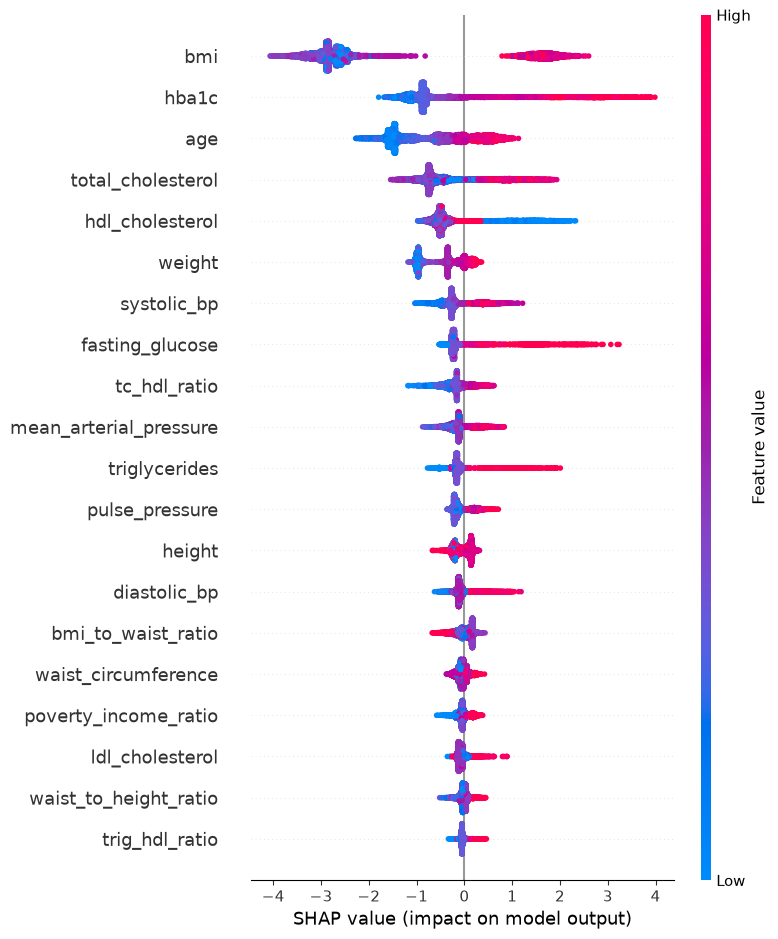

In [15]:
shap.summary_plot(
    shap_values,
    X_processed_df,
    max_display=20
)

### STEP 8 - SHAP Bar Plot

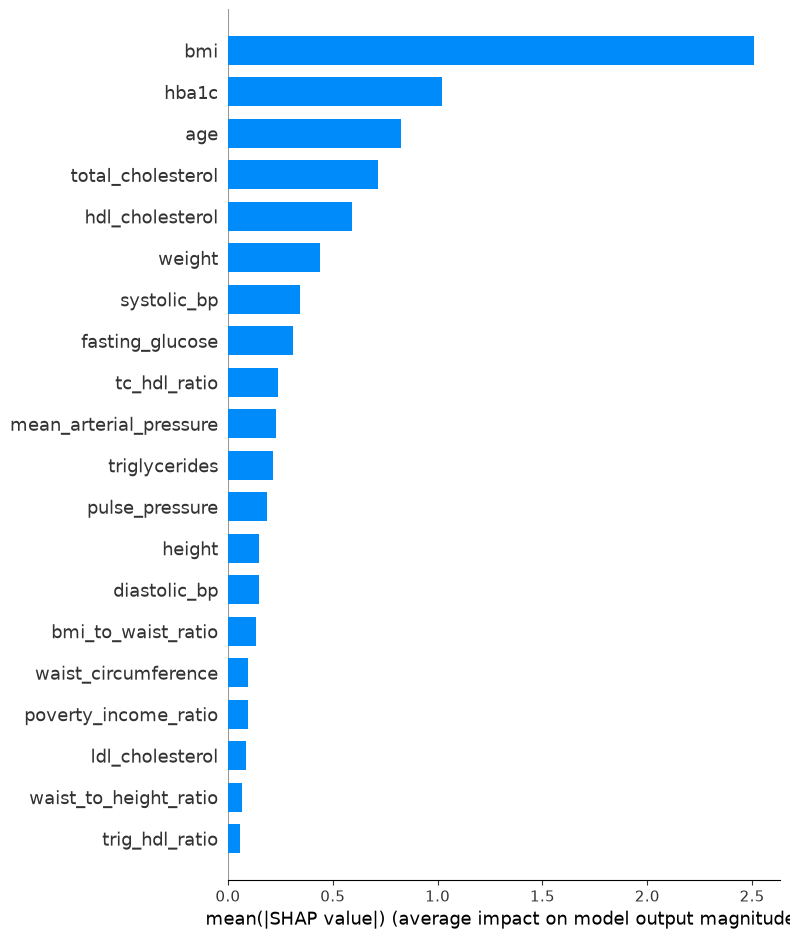

In [16]:


shap.summary_plot(
    shap_values,
    X_processed_df,
    plot_type="bar",
    max_display=20
)

###  STEP 9 - Local Patient Explanation

- Features pushing risk upward increase the probability of high risk.

- Features pushing risk downward reduce the probability of high risk.

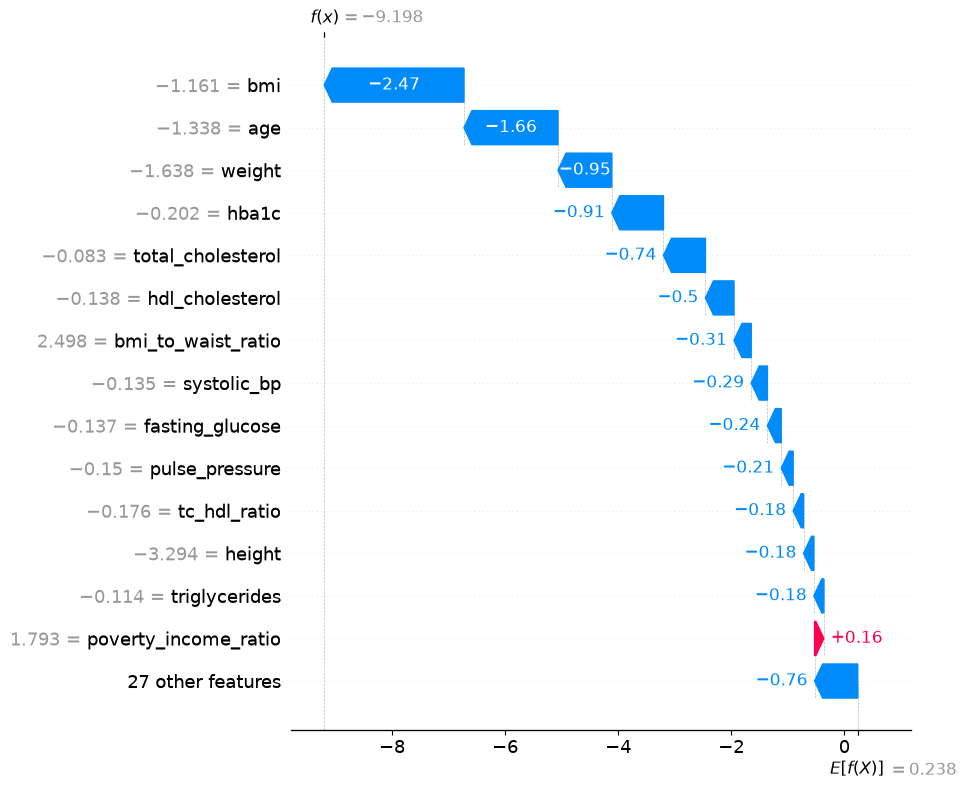

In [17]:
sample_index = 0

shap.waterfall_plot(
    shap.Explanation(
        values=shap_values[sample_index],
        base_values=explainer.expected_value,
        data=X_processed_df.iloc[sample_index],
        feature_names=X_processed_df.columns
    ),
    max_display=15
)

### STEP 10 - Save Feature Importance

In [18]:
shap_importance = pd.DataFrame({
    "feature": X_processed_df.columns,
    "mean_abs_shap": np.abs(shap_values).mean(axis=0)
}).sort_values("mean_abs_shap", ascending=False)

shap_importance.to_csv(
    os.path.join(DATA_PROCESSED, "cardioguard_shap_importance.csv"),
    index=False
)

shap_importance.head(20)

,feature,mean_abs_shap
5,bmi,2.507512
16,hba1c,1.022017
0,age,0.823914
18,total_cholesterol,0.717854
19,hdl_cholesterol,0.592957
7,weight,0.437682
11,systolic_bp,0.344544
15,fasting_glucose,0.308756
22,tc_hdl_ratio,0.238858
14,mean_arterial_pressure,0.227467


SHAP explains which features pushed participants toward or away from high cardiometabolic risk.

Globally, the most important features represent the strongest risk drivers across the population.

Locally, the waterfall plot explains one participant’s prediction by showing which features increased or reduced their predicted risk.